# 特征值、特征向量与 PCA 直觉 - 可视化

本 Notebook 生成三张图：
1. 矩阵变换下特征向量方向不变
2. 不同投影方向的方差对比
3. PCA 第一主成分示意

输出目录：`assets/`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

assets_dir = Path.cwd() / 'assets'
assets_dir.mkdir(parents=True, exist_ok=True)
assets_dir

WindowsPath('D:/BBFEC-FRONT/RL-AND-RL/01_数学基础/02_线性代数/assets')

## 图1：矩阵变换与特征向量方向

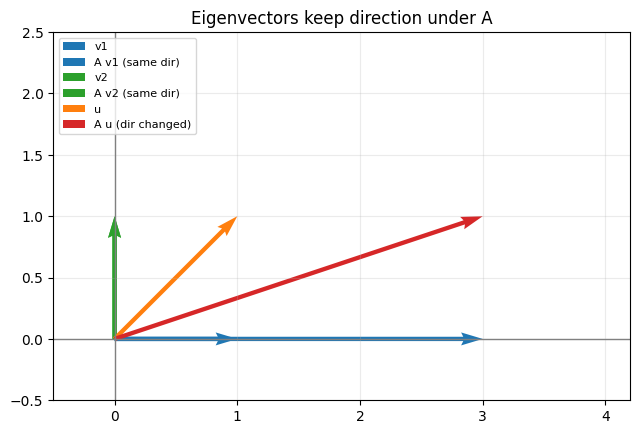

In [2]:
A = np.array([[3.0, 0.0], [0.0, 1.0]])
v1 = np.array([1.0, 0.0])  # eigenvector of lambda=3
v2 = np.array([0.0, 1.0])  # eigenvector of lambda=1
u  = np.array([1.0, 1.0])  # non-eigen direction

Av1, Av2, Au = A@v1, A@v2, A@u

plt.figure(figsize=(6.5,6))
plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)

def q(vec, c, label):
    plt.quiver(0,0,vec[0],vec[1],angles='xy',scale_units='xy',scale=1,color=c,label=label)

q(v1,'tab:blue','v1')
q(Av1,'tab:blue','A v1 (same dir)')
q(v2,'tab:green','v2')
q(Av2,'tab:green','A v2 (same dir)')
q(u,'tab:orange','u')
q(Au,'tab:red','A u (dir changed)')

plt.xlim(-0.5,4.2)
plt.ylim(-0.5,2.5)
plt.gca().set_aspect('equal','box')
plt.grid(alpha=0.25)
plt.title('Eigenvectors keep direction under A')
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(assets_dir / '19_eigen_direction.png', dpi=160)
plt.show()

## 生成一组二维相关数据

In [3]:
rng = np.random.default_rng(42)
n = 300
x = rng.normal(0, 1.2, n)
y = 0.7*x + rng.normal(0, 0.5, n)
X = np.column_stack([x, y])

# 中心化
Xc = X - X.mean(axis=0, keepdims=True)
cov = np.cov(Xc.T, bias=True)
eigvals, eigvecs = np.linalg.eigh(cov)
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]
pc1 = eigvecs[:, 0]

## 图2：投影方向与方差

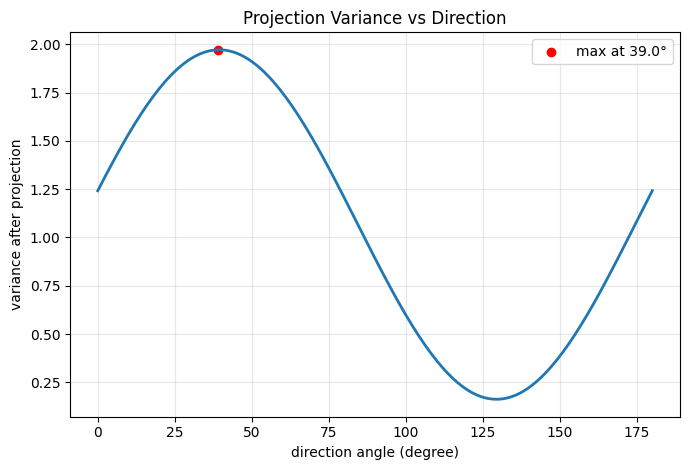

In [4]:
angles = np.linspace(0, np.pi, 181)
vars_ = []
for a in angles:
    d = np.array([np.cos(a), np.sin(a)])
    proj = Xc @ d
    vars_.append(np.var(proj))
vars_ = np.array(vars_)

best_idx = np.argmax(vars_)
best_angle_deg = np.degrees(angles[best_idx])

plt.figure(figsize=(7,4.8))
plt.plot(np.degrees(angles), vars_, linewidth=2)
plt.scatter([best_angle_deg], [vars_[best_idx]], c='red', label=f'max at {best_angle_deg:.1f}°')
plt.title('Projection Variance vs Direction')
plt.xlabel('direction angle (degree)')
plt.ylabel('variance after projection')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(assets_dir / '20_projection_variance.png', dpi=160)
plt.show()

## 图3：PCA 第一主成分示意

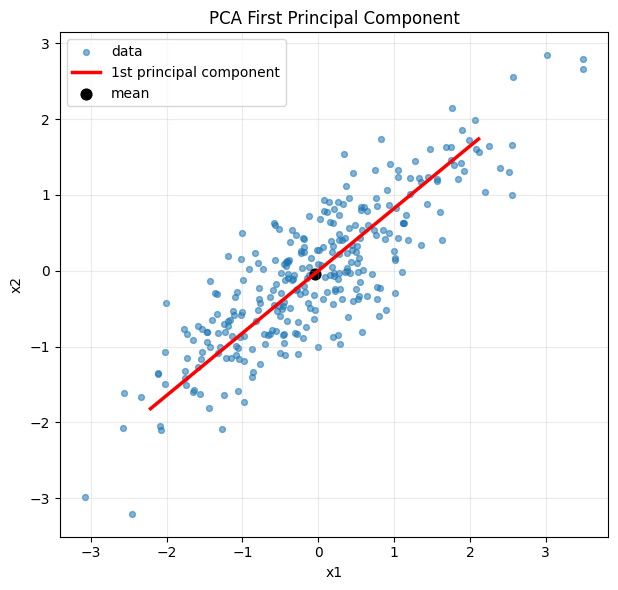

In [5]:
mean = X.mean(axis=0)
scale = 2.8
p1 = mean - scale*pc1
p2 = mean + scale*pc1

plt.figure(figsize=(6.5,6))
plt.scatter(X[:,0], X[:,1], s=18, alpha=0.55, label='data')
plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'r-', linewidth=2.5, label='1st principal component')
plt.scatter([mean[0]], [mean[1]], c='black', s=60, label='mean')
plt.title('PCA First Principal Component')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(alpha=0.25)
plt.legend()
plt.gca().set_aspect('equal','box')
plt.tight_layout()
plt.savefig(assets_dir / '21_pca_first_component.png', dpi=160)
plt.show()

### 输出文件
- `assets/19_eigen_direction.png`
- `assets/20_projection_variance.png`
- `assets/21_pca_first_component.png`